## Generate a Lorenz-63 chaotic trajectory

$$\frac{dx}{dt} = \sigma (y-x)$$
$$\frac{dy}{dt} = x (\rho-z)-y$$
$$\frac{dz}{dt} = xy - \beta z$$


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from utils.lorenz63 import lorenz

out_times = np.arange(0, 1000, 0.02)
xstate, ystate, zstate = 1.0, 1.0, 1.0
rho, beta, sigma = 28.0, 8.0/3.0, 10.0 #chaos

out = lorenz(time_series=out_times, init_state=[xstate, ystate, zstate], parameters=[rho, beta, sigma])

## Lorenz-63 phase space trajectory

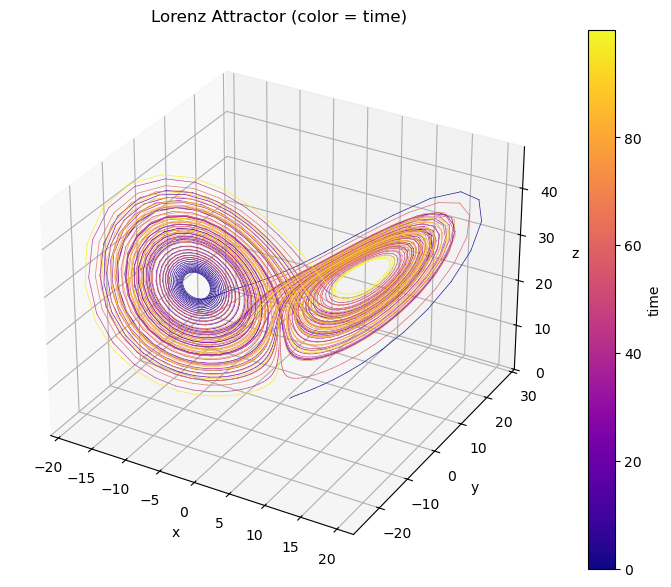

In [2]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

time_mask = (out_times < 100)
x, y, z = out[time_mask, 0], out[time_mask, 1], out[time_mask, 2]
t = out_times[time_mask]

# Normalize time for colormap
norm = plt.Normalize(t.min(), t.max())
cmap = plt.cm.plasma
colors = cmap(norm(t))

# Draw line as segments so each span can be colored by time
for i in range(len(x) - 1):
    ax.plot(x[i:i+2], y[i:i+2], z[i:i+2], color=colors[i], linewidth=0.5, alpha=0.9)

ax.set_title("Lorenz Attractor (color = time)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label="time")

## Temporal evolution of the state variables

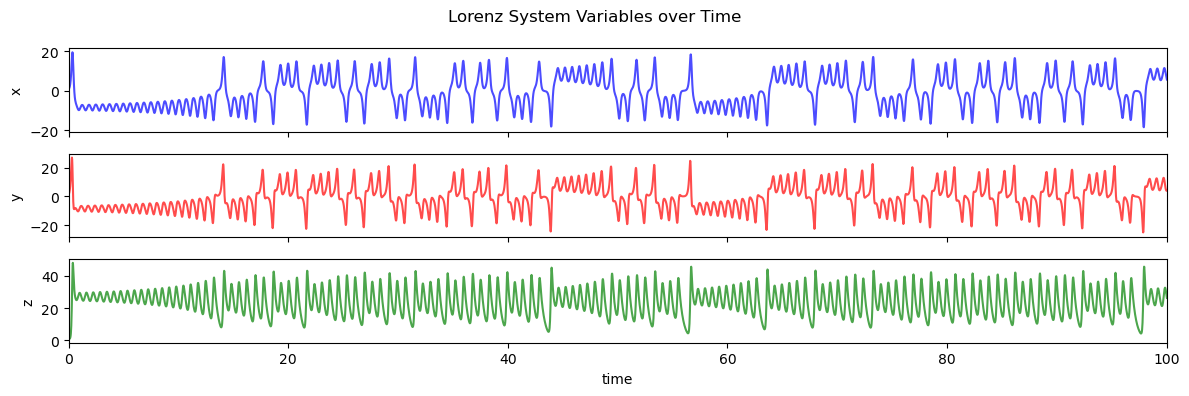

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=True)

axes[0].plot(out_times, out[:, 0], color='blue', alpha=0.7)
axes[0].set_ylabel("x")

axes[1].plot(out_times, out[:, 1], color='red', alpha=0.7)
axes[1].set_ylabel("y")

axes[2].plot(out_times, out[:, 2], color='green', alpha=0.7)
axes[2].set_ylabel("z")
axes[2].set_xlabel("time")

axes[0].set_xlim(0,100)

fig.suptitle("Lorenz System Variables over Time")
plt.tight_layout()
plt.show()

## Remove transients and normalize the state variables

In [4]:
x=out[out_times>100,:]
times=out_times[out_times>100]
import sklearn
scaler= sklearn.preprocessing.StandardScaler()
x_scaled = scaler.fit_transform(x)
print(x.shape)


(44999, 3)


## Lift data into feature space

In [5]:
def random_fourier_features(x: np.ndarray, D_out: int, sigma: float = 1.0, seed: int = None) -> np.ndarray:
    """
    Random Fourier Features (Rahimi & Recht, 2007) approximating the RBF kernel.

    Maps inputs x ~ [N, D] to z(x) ~ [N, 2*D_out] such that:
        z(x)ᵀ z(y)  ≈  k(x, y) = exp(-‖x - y‖² / (2σ²))

    Args:
        x:     Input array of shape [N, D], assumed normalized
        D_out: Number of random frequency samples (output dim = 2*D_out)
        sigma: RBF kernel bandwidth (default 1.0 for normalized inputs)
        seed:  Optional random seed for reproducibility

    Returns:
        z: Feature matrix of shape [N, 2*D_out]
    """
    rng = np.random.default_rng(seed)
    N, D = x.shape

    # Sample random frequencies from the spectral density of the RBF kernel:
    # p(w) = N(0, 1/σ² I)  (Fourier dual of the Gaussian kernel)
    W = rng.normal(loc=0.0, scale=1.0 / sigma, size=(D, D_out))  # [D, D_out]

    # Sample random phases uniformly in [0, 2π]
    b = rng.uniform(0, 2 * np.pi, size=(D_out,))                 # [D_out]

    # Project inputs: [N, D] @ [D, D_out] + [D_out] -> [N, D_out]
    z = x @ W + b                                                 # [N, D_out]

    # Approximate kernel via cos+sin embedding (variance-reduced form)
    # Using [cos, sin] avoids the random phase b and halves variance
    projection = x @ W                                            # [N, D_out]
    z = np.sqrt(1.0 / D_out) * np.concatenate(
        [np.cos(projection), np.sin(projection)], axis=1
    )                                                             # [N, 2*D_out]

    z = np.hstack([x, z])  # Include original features for linear terms
    return z

from itertools import combinations_with_replacement

def polynomial_features(x: np.ndarray, m: int) -> np.ndarray:
    """
    Generate all polynomial features up to degree m for input array x.

    Args:
        x: Input array of shape [N, D]
        m: Maximum polynomial degree

    Returns:
        Array of shape [N, P] where P is the number of polynomial features.
        Does not include the bias term (degree 0).
    """
    N, D = x.shape
    features = []  

    for degree in range(1, m + 1):
        # All combinations with replacement gives monomials of exactly `degree`
        for combo in combinations_with_replacement(range(D), degree):
            # Multiply the selected columns together: x[:,i] * x[:,j] * ...
            term = np.prod(x[:, combo], axis=1, keepdims=True)
            features.append(term)

    return np.hstack(features)

## Learn linear dynamics in feature space

In [6]:
def get_features(x_scaled):
    x_koopman = random_fourier_features(x_scaled, D_out=500, sigma=0.5, seed=42)
    #x_koopman = polynomial_features(x_scaled, m=5)
    return x_koopman

x_koopman = get_features(x_scaled)
print(x_koopman.shape)


regressor = sklearn.linear_model.LinearRegression()
regressor.fit(x_koopman[:-1,:], x_koopman[1:,:])


(44999, 1003)


LinearRegression()

## Predict dynamics using learned Koopman model

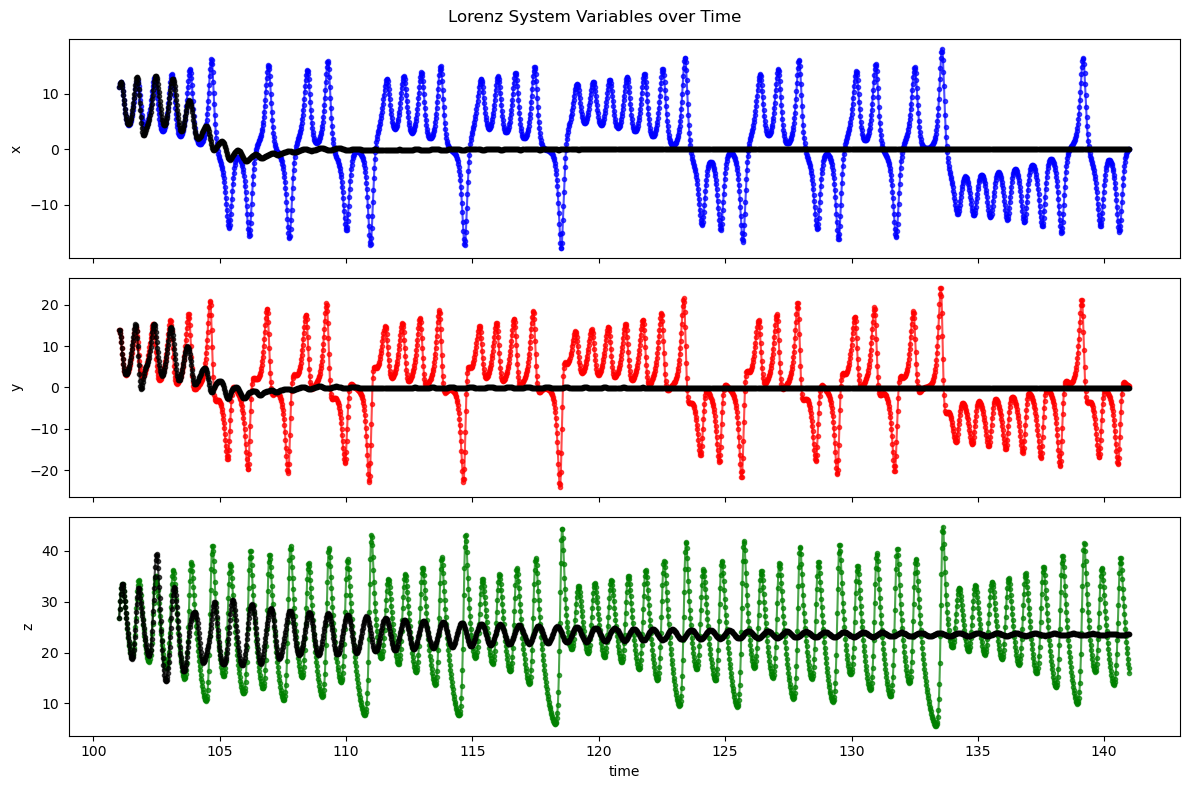

In [7]:
# choose sinitial condition and number of prediction steps
t_0 = 50
n_steps = 2000

x_koopman_pred = np.zeros_like(x_koopman[t_0:t_0+n_steps,:])
x_koopman_pred[0,:] = x_koopman[t_0,:]
for t in range(1, n_steps):
    x_koopman_pred[t,:] = regressor.predict(x_koopman_pred[t-1:t,:])

#x_koopman_pred_unscaled = koopman_scaler.inverse_transform(x_koopman_pred)
x_pred = scaler.inverse_transform(x_koopman_pred[:,:3])

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(times[t_0:t_0+n_steps], x[t_0:t_0+n_steps, 0], '.-', color='blue', alpha=0.7)
axes[0].plot(times[t_0:t_0+n_steps], x_pred[:, 0], '.-k',  alpha=0.7)
axes[0].set_ylabel("x")

if x.shape[-1] > 1:  # Check if y variable exists
    axes[1].plot(times[t_0:t_0+n_steps], x[t_0:t_0+n_steps, 1], '.-', color='red', alpha=0.7)
    axes[1].plot(times[t_0:t_0+n_steps], x_pred[:, 1], '.-k',  alpha=0.7)
    axes[1].set_ylabel("y")

if x.shape[-1] > 2:  # Check if z variable exists
    axes[2].plot(times[t_0:t_0+n_steps], x[t_0:t_0+n_steps, 2], '.-', color='green', alpha=0.7)
    axes[2].plot(times[t_0:t_0+n_steps], x_pred[:, 2], '.-k',  alpha=0.7)
    axes[2].set_ylabel("z")
    axes[2].set_xlabel("time")

fig.suptitle("Lorenz System Variables over Time")
plt.tight_layout()
plt.show()

## Koopman rollout with recursive feature lifting

Equivalent to a simple nonlinear model

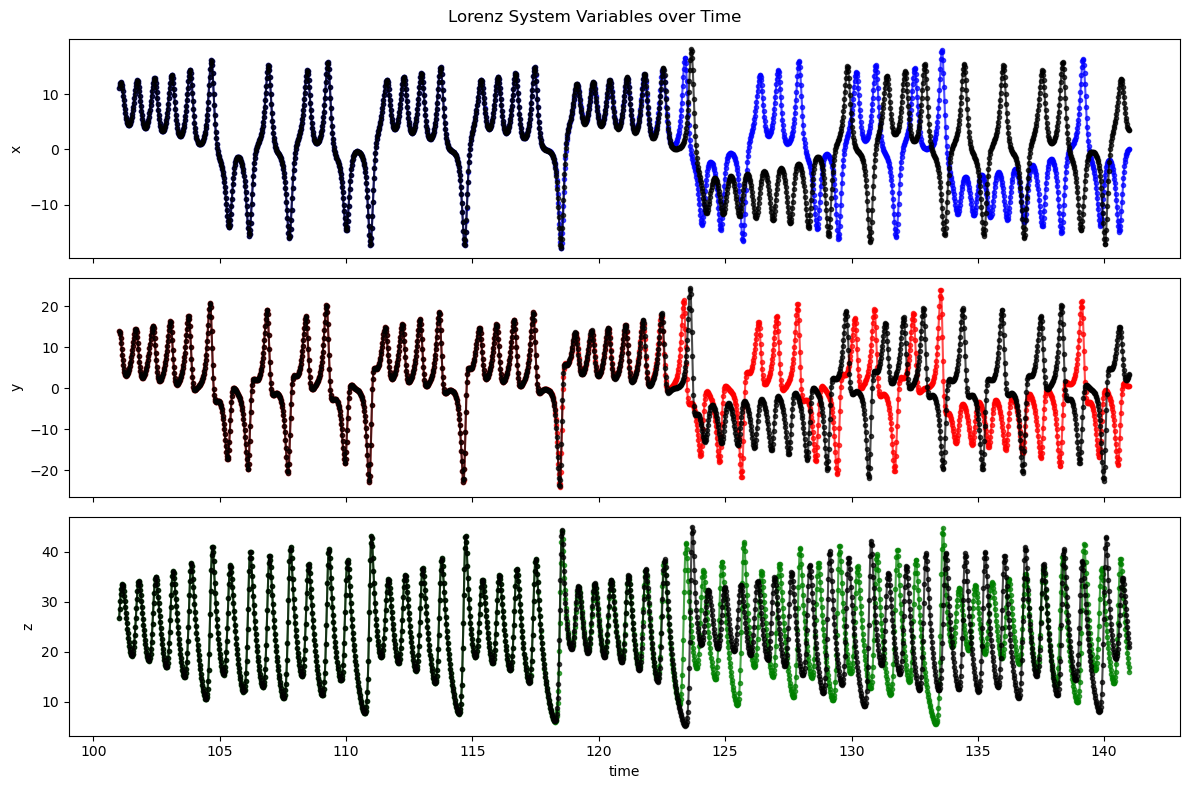

In [8]:
# choose initial condition and number of prediction steps
t_0 = 50
n_steps = 2000

x_koopman_pred = np.zeros_like(x_koopman[t_0:t_0+n_steps,:])
x_koopman_pred[0,:] = x_koopman[t_0,:]
for t in range(1, n_steps):
    x_koopman_pred[t,:] = regressor.predict(x_koopman_pred[t-1:t,:])
    # We only add this line of code
    x_koopman_pred[t:t+1,:] = get_features(x_koopman_pred[t:t+1,:x.shape[-1]])

    

#x_koopman_pred_unscaled = koopman_scaler.inverse_transform(x_koopman_pred)
x_pred = scaler.inverse_transform(x_koopman_pred[:,:3])

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(times[t_0:t_0+n_steps], x[t_0:t_0+n_steps, 0], '.-', color='blue', alpha=0.7)
axes[0].plot(times[t_0:t_0+n_steps], x_pred[:, 0], '.-k',  alpha=0.7)
axes[0].set_ylabel("x")

if x.shape[-1] > 1:  # Check if y variable exists
    axes[1].plot(times[t_0:t_0+n_steps], x[t_0:t_0+n_steps, 1], '.-', color='red', alpha=0.7)
    axes[1].plot(times[t_0:t_0+n_steps], x_pred[:, 1], '.-k',  alpha=0.7)
    axes[1].set_ylabel("y")
if x.shape[-1] > 2:  # Check if z variable exists
    axes[2].plot(times[t_0:t_0+n_steps], x[t_0:t_0+n_steps, 2], '.-', color='green', alpha=0.7)
    axes[2].plot(times[t_0:t_0+n_steps], x_pred[:, 2], '.-k',  alpha=0.7)
    axes[2].set_ylabel("z")
    axes[2].set_xlabel("time")

fig.suptitle("Lorenz System Variables over Time")
plt.tight_layout()
plt.show()